In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


## KNN

In [3]:
applicant_df = pd.read_csv('CustomerLoan.csv')
applicant_df.head()

,Name,income,score,default
0,0,78479,800,NO
1,1,95483,801,NO
2,2,101641,815,NO
3,3,104234,790,NO
4,4,108726,795,NO


In [6]:
applicant_df['income_Normalized'] = ((applicant_df['income'] - applicant_df['income'].min())/
 (applicant_df['income'].max()-applicant_df['income'].min()))

In [8]:
applicant_df['score_Normalized'] = ((applicant_df['score'] - applicant_df['score'].min())/
 (applicant_df['score'].max()-applicant_df['score'].min()))

In [9]:
applicant_df.head()

,Name,income,score,default,income_Normalized,score_Normalized
0,0,78479,800,NO,0.000000,0.888889
1,1,95483,801,NO,0.409765,0.896296
2,2,101641,815,NO,0.558161,1.000000
3,3,104234,790,NO,0.620647,0.814815
4,4,108726,795,NO,0.728896,0.851852


In [10]:
from sklearn.neighbors import KNeighborsClassifier

In [11]:
predictors = ['income_Normalized','score_Normalized']
target = 'default'
Xs = applicant_df[predictors].drop(index=[20])
y=applicant_df[target].drop(index=[20])

In [12]:
knn=KNeighborsClassifier(n_neighbors=5)
knn.fit(Xs,y)

KNeighborsClassifier()

In [15]:
newApplicant = pd.DataFrame({'income_Normalized':applicant_df.iloc[20].income_Normalized,
                             'score_Normalized':applicant_df.iloc[20].score_Normalized},
                             index=[20])
predict_y = knn.predict(newApplicant)
print(predict_y)

['NO']


## Decision Trees

In [16]:
from sklearn.tree import DecisionTreeClassifier

In [20]:
predictors = ['income','score']
target = 'default'
Xs = applicant_df[predictors].drop(index=[20])
y=applicant_df[target].drop(index=[20])

In [21]:
classTree = DecisionTreeClassifier()
classTree.fit(Xs,y)

DecisionTreeClassifier()

In [23]:
newApplicant = pd.DataFrame({'income': 
                             applicant_df.iloc[20].income,
                             'score': 
                             applicant_df.iloc[20].score},
                            index = [20])
predict_y = classTree.predict(newApplicant)
print(predict_y)

['Yes']


In [24]:
from sklearn.tree import plot_tree

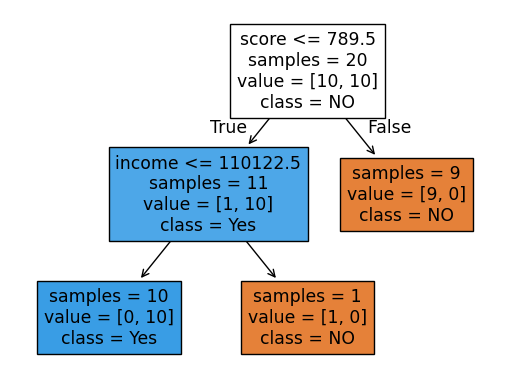

In [26]:
plot_tree(classTree,
          feature_names=predictors,
          class_names=y.unique(),
          filled=True,
          impurity=False);